In [1]:
import os
os.chdir('..')
if os.path.exists('Groenbeeld'):
  !rm -rf Groenbeeld

In [2]:
import sys
!{sys.executable} -m pip install owslib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.5/240.5 kB 3.5 MB/s eta 0:00:00


In [3]:
import os

!git clone https://github.com/bart314/Groenbeeld.git
os.chdir('Groenbeeld')
!git checkout clustering
!ls

Cloning into 'Groenbeeld'...
remote: Enumerating objects: 223, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 223 (delta 43), reused 40 (delta 15), pack-reused 139 (from 1)
Receiving objects: 100% (223/223), 11.34 MiB | 19.31 MiB/s, done.
Resolving deltas: 100% (107/107), done.
Branch 'clustering' set up to track remote branch 'clustering' from 'origin'.
Switched to a new branch 'clustering'
Data	    NDVI-SWF.yaml  README.md  targets.txt
LICENSE.md  outdir	   Scripts    Tutorial_grondwaterstand


In [4]:
import os

# Define the expected output path for the CIR data from the previous script.
# This assumes 'outdir/municipality_survey_V2/BU19000102_Stationsbuurt_CIR.tif'
# is a reliable indicator that the script has already run successfully.
output_dir = 'outdir/municipality_survey_V2'
target_id_prefix = 'BU19000102_Stationsbuurt' # Based on previous script output and subsequent cell usage
expected_output_file = os.path.join(output_dir, f"{target_id_prefix}_CIR.tif")

# Ensure the output directory structure is created for the check
os.makedirs(output_dir, exist_ok=True)

if os.path.exists(expected_output_file):
    print(f"Detected existing output file: {expected_output_file}. Skipping `Municipality_Surveyor_V2.py` execution.")
else:
    print(f"Output file {expected_output_file} not found. Running `Municipality_Surveyor_V2.py` to generate data...")
    !python3 "Scripts/Municipality_Surveyor_V2.py"

Output file outdir/municipality_survey_V2/BU19000102_Stationsbuurt_CIR.tif not found. Running `Municipality_Surveyor_V2.py` to generate data...
Loaded 1 targets from targets.txt
Initializing CIR WMTS service...
Initializing RGB WMTS service...
Initiatlizing BRT WMTS service...
Initializing BRT-A Background service...
Initializing BGT WMTS service...
WMTS initialized. Resolution: 0.21m/px
Initializing KEA WMS service...
Connecting to Sogelink Server for ['gevoelstemperatuur_2022', 'RMK_BKB_AHN4', 'RMK_SchaduwGrijs_AHN4', 'RMK_SchaduwGroen_AHN4', 'BGV_ONO_2024', 'BGV_landbedekking_2024', 'RMK_30percBKB_AHN4']...
 SUCCESS: Layer 'gevoelstemperatuur_2022' found.
 SUCCESS: Layer 'RMK_BKB_AHN4' found.
 SUCCESS: Layer 'RMK_SchaduwGrijs_AHN4' found.
 SUCCESS: Layer 'RMK_SchaduwGroen_AHN4' found.
 SUCCESS: Layer 'BGV_ONO_2024' found.
 SUCCESS: Layer 'BGV_landbedekking_2024' found.
 SUCCESS: Layer 'RMK_30percBKB_AHN4' found.
 ERROR: Could not retrieve capabilities.
Fetching all buurten for Súdwe

In [5]:
!python3 "/Groenbeeld/Scripts/Exploratory_Clustering.py"

Loaded 1 targets from targets.txt

Processing Target: BU19000102
Error: Could not find all required TIF files for BU19000102 in outdir/municipality_survey


In [6]:
import sys
!{sys.executable} -m pip install rasterio matplotlib

Current working directory already Groenbeeld: /Groenbeeld
Current working directory: /Groenbeeld
Checking for directory: outdir/municipality_survey_V2

--- Contents of 'outdir' (recursive) ---
outdir:
exploratory_analysis  Jenks_stat_2.txt
Jenks_counts.npy      municipality_survey_V2

outdir/exploratory_analysis:
Stationsbuurt_clusters.qml	 Stationsbuurt_elbow_plot.png
Stationsbuurt_cluster_stats.csv

outdir/municipality_survey_V2:
BU19000102_Stationsbuurt_BGT.tif
BU19000102_Stationsbuurt_BRTA.tif
BU19000102_Stationsbuurt_BRT.tif
BU19000102_Stationsbuurt_CHM.tif
BU19000102_Stationsbuurt_CIR.tif
BU19000102_Stationsbuurt_DSM.tif
BU19000102_Stationsbuurt_DTM.tif
BU19000102_Stationsbuurt_KEA_BGV_landbedekking_2024.tif
BU19000102_Stationsbuurt_KEA_BGV_ONO_2024.tif
BU19000102_Stationsbuurt_KEA_gevoelstemperatuur_2022.tif
BU19000102_Stationsbuurt_KEA_RMK_30percBKB_AHN4.tif
BU19000102_Stationsbuurt_KEA_RMK_BKB_AHN4.tif
BU19000102_Stationsbuurt_KEA_RMK_SchaduwGrijs_AHN4.tif
BU19000102_Stationsb

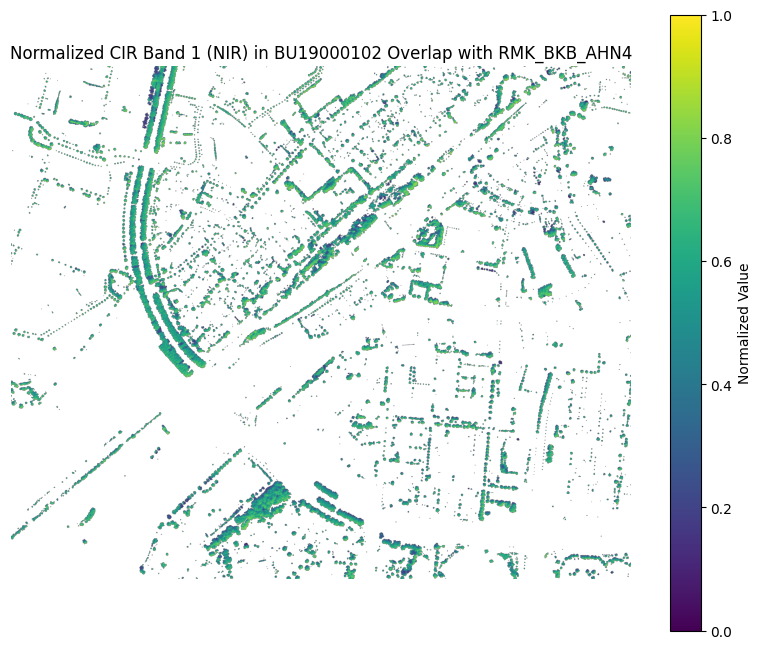

Normalized CIR map saved to: outdir/BU19000102_CIR_RMK_BKB_AHN4_normalized.tif


In [7]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Ensure current working directory is 'Groenbeeld' for relative paths to work correctly
if os.path.basename(os.getcwd()) != 'Groenbeeld':
    print(f"Changing directory from {os.getcwd()} to /content/Groenbeeld")
    os.chdir('/content/Groenbeeld')
    print(f"Current working directory is now: {os.getcwd()}")
else:
    print(f"Current working directory already Groenbeeld: {os.getcwd()}")


# Assuming the current working directory is 'Groenbeeld'
base_output_dir = 'outdir/municipality_survey_V2'
target_id = 'BU19000102'
# Fix: The output files are directly in base_output_dir, not in a subfolder named target_id
neighborhood_dir = base_output_dir # Corrected line

print(f"Current working directory: {os.getcwd()}")
print(f"Checking for directory: {neighborhood_dir}")

# Diagnostic: List contents of 'outdir' to understand actual structure
print("\n--- Contents of 'outdir' (recursive) ---")
!ls -R outdir
print("--------------------------------------\n")

if os.path.exists(neighborhood_dir):
    for f in os.listdir(neighborhood_dir):
        # Diagnostic: Only print files if they match the expected pattern or are relevant
        if target_id in f or f.endswith(('.npy', '.tif')):
            print(f)
else:
    print(f"Directory not found: {neighborhood_dir}")
    raise FileNotFoundError(f"Required directory {neighborhood_dir} does not exist.")

# Determine the full neighborhood name for correct file paths
# From the `ls` output and previous script's logs, it appears the full name is 'BU19000102_Stationsbuurt'
neighborhood_full_name = f"{target_id}_Stationsbuurt"

# Define file paths for the CIR data (now from a TIFF) and the KEA layer
cir_data_path = os.path.join(neighborhood_dir, f"{neighborhood_full_name}_CIR.tif")
kea_layer_path = os.path.join(neighborhood_dir, f"{neighborhood_full_name}_KEA_RMK_BKB_AHN4.tif")
geo_ref_path = os.path.join(neighborhood_dir, f"{neighborhood_full_name}_DSM.tif") # Use DSM for georeferencing

# Check if all necessary files exist
if not os.path.exists(cir_data_path):
    raise FileNotFoundError(f"Error: CIR data file not found at {cir_data_path}")
if not os.path.exists(kea_layer_path):
    raise FileNotFoundError(f"Error: KEA layer file not found at {kea_layer_path}")
if not os.path.exists(geo_ref_path):
    raise FileNotFoundError(f"Error: Georeference file not found at {geo_ref_path}")

# Load CIR array from .tif file using rasterio
cir_map = None
try:
    with rasterio.open(cir_data_path) as src_cir:
        # Assuming CIR is a multi-band image (e.g., NIR-Red-Green)
        # Read all bands. Rasterio reads bands as (count, height, width)
        cir_map = src_cir.read()
        print(f"Loaded CIR map from TIFF with shape: {cir_map.shape}")
except Exception as e:
    raise RuntimeError(f"Failed to load CIR data from {cir_data_path}: {e}")

# Load KEA layer (RMK_BKB_AHN4)
kea_profile = None
kea_data = None
try:
    with rasterio.open(kea_layer_path) as src_kea:
        kea_data = src_kea.read(1) # Read the first band
        kea_profile = src_kea.profile
        print(f"Loaded KEA layer with shape: {kea_data.shape}")
        print(f"KEA layer profile: {kea_profile}")
except Exception as e:
    raise RuntimeError(f"Failed to load KEA layer from {kea_layer_path}: {e}")

# Get georeferencing information from a reference GeoTIFF (e.g., DSM.tif)
geo_ref_profile = None
try:
    with rasterio.open(geo_ref_path) as src_ref:
        geo_ref_profile = src_ref.profile
        print(f"Georeference profile from {geo_ref_path}: {geo_ref_profile}")
except Exception as e:
    raise RuntimeError(f"Failed to load georeference data from {geo_ref_path}: {e}")

# Ensure all data is loaded and dimensions match
expected_height = geo_ref_profile['height']
expected_width = geo_ref_profile['width']

if cir_map.shape[1] != expected_height or cir_map.shape[2] != expected_width:
    raise ValueError(f"CIR map dimensions ({cir_map.shape[1]}, {cir_map.shape[2]}) "
                     f"do not match reference GeoTIFF dimensions ({expected_height}, {expected_width}).")

if kea_data.shape[0] != expected_height or kea_data.shape[1] != expected_width:
    raise ValueError(f"KEA layer dimensions ({kea_data.shape}) do not match reference GeoTIFF dimensions ({expected_height}, {expected_width}).")

print("CIR map and KEA layer dimensions are consistent with reference GeoTIFF.")

# Create an overlap mask from kea_data
# Assuming non-zero values in `kea_data` indicate the region of interest for overlap
overlap_mask = kea_data > 0

# Apply the mask to each band of the CIR map
masked_cir = np.empty_like(cir_map, dtype=float)
for i in range(cir_map.shape[0]):
    band_data = cir_map[i, :, :].astype(float) # Ensure float for calculations
    band_data[~overlap_mask] = np.nan # Set non-overlap regions to NaN
    masked_cir[i, :, :] = band_data

print(f"Masked CIR map shape: {masked_cir.shape}")

# Normalize CIR values within the overlap region (min-max normalization to 0-1)
normalized_masked_cir = np.empty_like(masked_cir)

for i in range(masked_cir.shape[0]):
    band_values = masked_cir[i, :, :]
    valid_values = band_values[~np.isnan(band_values)]

    if valid_values.size > 0:
        min_val = np.min(valid_values)
        max_val = np.max(valid_values)

        if max_val - min_val > 0:
            normalized_band = (band_values - min_val) / (max_val - min_val)
            # Restore NaN for non-overlap regions
            normalized_band[np.isnan(band_values)] = np.nan
        else: # All valid values are the same in the overlap region
            normalized_band = np.full_like(band_values, np.nan)
            normalized_band[~np.isnan(band_values)] = 0.5 # Set to mid-range if all values are constant
    else: # No valid values in this band for the overlap region
        normalized_band = np.full_like(band_values, np.nan)

    normalized_masked_cir[i, :, :] = normalized_band

print(f"Normalized masked CIR map shape: {normalized_masked_cir.shape}")
print("Normalization complete. Values in overlap region are scaled between 0 and 1 (or NaN elsewhere).")

# Visualize a band of the normalized CIR map (e.g., the first band)
plt.figure(figsize=(10, 8))
plt.imshow(normalized_masked_cir[0, :, :], cmap='viridis', vmin=0, vmax=1)
plt.title(f"Normalized CIR Band 1 (NIR) in {target_id} Overlap with RMK_BKB_AHN4")
plt.colorbar(label="Normalized Value")
plt.axis('off')
plt.show()

# Save the normalized CIR map as a GeoTIFF
output_profile = geo_ref_profile.copy()
output_profile.update({
    'dtype': rasterio.float32,
    'count': cir_map.shape[0], # Number of bands in CIR
    'nodata': np.nan # Use NaN as nodata value
})

# Define the user-specified output directory
user_output_dir = 'outdir'

# Create the output directory if it doesn't exist
os.makedirs(user_output_dir, exist_ok=True)

output_path = os.path.join(user_output_dir, f"{target_id}_CIR_RMK_BKB_AHN4_normalized.tif")
try:
    with rasterio.open(output_path, 'w', **output_profile) as dst:
        for i in range(normalized_masked_cir.shape[0]):
            dst.write(normalized_masked_cir[i].astype(rasterio.float32), i + 1)
    print(f"Normalized CIR map saved to: {output_path}")
except Exception as e:
    print(f"Error saving normalized CIR map: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.0/642.0 kB 6.4 MB/s eta 0:00:00
Sampling 100000 values from 6644672 for Jenks breaks calculation...
Jenks natural breaks for 5 classes: [np.float64(0.05), np.float64(0.32272727272727275), np.float64(0.4636363636363636), np.float64(0.5772727272727273), np.float64(0.6818181818181818), np.float64(0.9863636363636363)]


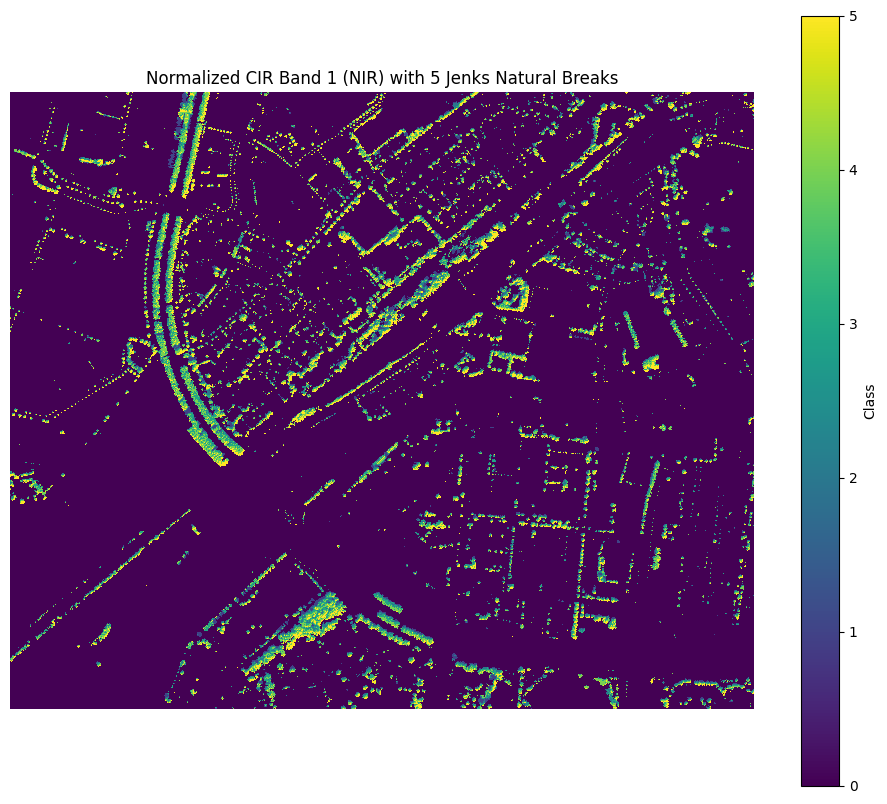

In [8]:
import sys
!{sys.executable} -m pip install jenkspy
import jenkspy
import numpy as np
import matplotlib.pyplot as plt

# Extract valid (non-NaN) values from the normalized masked CIR map (e.g., the first band)
valid_normalized_values = normalized_masked_cir[0, :, :][~np.isnan(normalized_masked_cir[0, :, :])]

# Define the number of classes for natural breaks
# You might want to experiment with this number (e.g., 3, 5, 7)
num_classes = 5

# --- Optimization for large datasets: Sample the data for Jenks breaks calculation ---
# Jenks breaks can be slow on very large arrays. Sampling can significantly reduce runtime.
sample_size = 100000 # Define a suitable sample size

if len(valid_normalized_values) > sample_size:
    # Take a random sample if the dataset is larger than the sample_size
    np.random.seed(42) # For reproducibility
    sampled_values = np.random.choice(valid_normalized_values, size=sample_size, replace=False)
    print(f"Sampling {sample_size} values from {len(valid_normalized_values)} for Jenks breaks calculation...")
else:
    sampled_values = valid_normalized_values
    print("Dataset size is smaller than or equal to sample_size, using all valid values for Jenks breaks.")
# -----------------------------------------------------------------------------------


# Calculate Jenks natural breaks
# Ensure there are enough unique values for the requested number of classes
if len(np.unique(sampled_values)) >= num_classes:
    breaks = jenkspy.jenks_breaks(sampled_values, n_classes=num_classes)
    print(f"Jenks natural breaks for {num_classes} classes: {breaks}")

    # Visualize the data using these natural breaks
    plt.figure(figsize=(12, 10))
    plt.imshow(normalized_masked_cir[0, :, :], cmap='viridis', vmin=0, vmax=1)

    # Overlay the breaks as contours or use a custom colormap based on breaks
    # For simplicity, let's create a categorized map based on breaks
    categorized_map = np.zeros_like(normalized_masked_cir[0, :, :], dtype=int)
    for i in range(num_classes):
        lower_bound = breaks[i]
        upper_bound = breaks[i+1]
        # Assign a category index to values falling within each break
        categorized_map[np.logical_and(normalized_masked_cir[0, :, :] >= lower_bound, normalized_masked_cir[0, :, :] < upper_bound)] = i + 1

    # Handle the highest class upper bound (inclusive)
    # The last break point is inclusive for the highest class
    categorized_map[normalized_masked_cir[0, :, :] == breaks[-1]] = num_classes

    # Set NaN regions to 0 for plotting (or mask them for a cleaner look)
    categorized_map[np.isnan(normalized_masked_cir[0, :, :])] = 0 # Or use np.ma.masked_invalid

    # Plot the categorized map
    plt.imshow(categorized_map, cmap='viridis', interpolation='nearest', vmin=0, vmax=num_classes)
    plt.title(f"Normalized CIR Band 1 (NIR) with {num_classes} Jenks Natural Breaks")
    plt.colorbar(label="Class")
    plt.axis('off')
    plt.show()
elif len(np.unique(sampled_values)) < num_classes and len(np.unique(sampled_values)) > 1:
    # If there are fewer unique values than num_classes but more than 1, reduce num_classes
    print(f"Warning: Not enough unique values ({len(np.unique(sampled_values))}) for {num_classes} Jenks breaks. Reducing num_classes to {len(np.unique(sampled_values)) - 1}.")
    breaks = jenkspy.jenks_breaks(sampled_values, n_classes=len(np.unique(sampled_values)) - 1)
    num_classes = len(np.unique(sampled_values)) - 1
    print(f"Jenks natural breaks for {num_classes} classes: {breaks}")

    # Visualize the data using these natural breaks
    plt.figure(figsize=(12, 10))
    plt.imshow(normalized_masked_cir[0, :, :], cmap='viridis', vmin=0, vmax=1)

    # Overlay the breaks as contours or use a custom colormap based on breaks
    # For simplicity, let's create a categorized map based on breaks
    categorized_map = np.zeros_like(normalized_masked_cir[0, :, :], dtype=int)
    for i in range(num_classes):
        lower_bound = breaks[i]
        upper_bound = breaks[i+1]
        # Assign a category index to values falling within each break
        categorized_map[np.logical_and(normalized_masked_cir[0, :, :] >= lower_bound, normalized_masked_cir[0, :, :] < upper_bound)] = i + 1

    # Handle the highest class upper bound (inclusive)
    # The last break point is inclusive for the highest class
    categorized_map[normalized_masked_cir[0, :, :] == breaks[-1]] = num_classes

    # Set NaN regions to 0 for plotting (or mask them for a cleaner look)
    categorized_map[np.isnan(normalized_masked_cir[0, :, :])] = 0 # Or use np.ma.masked_invalid

    # Plot the categorized map
    plt.imshow(categorized_map, cmap='viridis', interpolation='nearest', vmin=0, vmax=num_classes)
    plt.title(f"Normalized CIR Band 1 (NIR) with {num_classes} Jenks Natural Breaks")
    plt.colorbar(label="Class")
    plt.axis('off')
    plt.show()
else:
    print(f"Not enough unique values ({len(np.unique(sampled_values))}) in the sampled data to calculate Jenks breaks. Skipping visualization.")

### Adaptive Segmentation with Superpixels

To create a more adaptive 'grid' that can break high-concentration areas into smaller, more meaningful sections, we can use **superpixel segmentation**. Superpixels group perceptually similar and spatially adjacent pixels into larger, coherent regions. We will then apply Jenks natural breaks to the mean values of these superpixels, rather than individual pixels.

In [9]:
import sys
!{sys.executable} -m pip install scikit-image

In [ ]:
from skimage.segmentation import slic
import numpy as np
import scipy.ndimage # Import ndimage for faster calculations

# Ensure normalized_masked_cir and overlap_mask are available
# We'll use the first band (NIR) which was used for pixel-based Jenks breaks
nir_band = normalized_masked_cir[0, :, :].copy() # Make a copy to avoid modifying original

# Handle NaNs: SLIC cannot operate on NaN values. Replace with 0.0 (background).
nir_band_no_nan = np.nan_to_num(nir_band, nan=0.0)

# Apply SLIC superpixel segmentation
# n_segments: approximate number of superpixels. Adjust for desired granularity.
# compactness: balances color proximity and space proximity (higher = more compact, squarer superpixels).
# sigma: width of Gaussian smoothing kernel for pre-processing.
# start_label=1: ensures superpixel labels start from 1, so 0 can remain 'no data'.
# mask=overlap_mask: ensures superpixels are only generated within the valid vegetation area.
segments = slic(nir_band_no_nan, n_segments=10000, compactness=10, sigma=1,
                start_label=1, mask=overlap_mask, channel_axis=None)

print(f"Generated {segments.max()} superpixels.")

# Calculate mean NIR value for each superpixel
# Optimization: Use scipy.ndimage for faster calculation of means per segment.
# First, create a version of nir_band where only pixels within overlap_mask are considered, others are NaN.
nir_band_for_stats = nir_band.copy()
nir_band_for_stats[~overlap_mask] = np.nan

# Calculate mean for each segment, ignoring NaNs.
# ndimage.mean returns an array where each element corresponds to the mean of a label.
max_segment_id = segments.max()
# Compute means for all segment IDs from 1 to max_segment_id
calculated_means = scipy.ndimage.mean(
    input=nir_band_for_stats,
    labels=segments,
    index=np.arange(1, max_segment_id + 1) # Specify labels to calculate for
)

superpixel_means = np.full(max_segment_id + 1, np.nan)
superpixel_means[1:max_segment_id + 1] = calculated_means # Assign calculated means to correct segment IDs

# Filter out NaN means if any (superpixels completely outside the valid area or with no valid NIR data)
valid_superpixel_means = superpixel_means[~np.isnan(superpixel_means)]

print(f"Calculated mean NIR for {len(valid_superpixel_means)} valid superpixels.")

In [ ]:
import jenkspy
import matplotlib.pyplot as plt
import numpy as np
import gc # Import garbage collector for memory management

# Assume superpixel_means, segments, overlap_mask, num_classes (from previous cell) are available

if len(valid_superpixel_means) >= num_classes:
    # Calculate Jenks breaks on the mean superpixel values
    jenks_breaks_superpixels = jenkspy.jenks_breaks(valid_superpixel_means, n_classes=num_classes)
    print(f"Jenks natural breaks for {num_classes} classes on superpixel means: {jenks_breaks_superpixels}")

    # --- Optimized Categorization for RAM usage ---
    # Prepare an array to store class for each superpixel ID
    max_segment_id = segments.max()
    # Use np.uint8 to minimize memory footprint, as classes are small positive integers.
    superpixel_class_lookup = np.zeros(max_segment_id + 1, dtype=np.uint8)

    # Identify valid superpixel IDs and their mean values
    valid_seg_ids = np.where(~np.isnan(superpixel_means))[0]
    valid_means_for_lookup = superpixel_means[valid_seg_ids]

    # Calculate class indices for valid superpixel means using np.digitize
    # np.digitize returns 1-based indices for bins, which directly map to our classes (1 to num_classes).
    # Values less than the first break will get 0, which is correct for background.
    class_indices = np.digitize(valid_means_for_lookup, jenks_breaks_superpixels)
    # Ensure class_indices are also uint8 to save memory
    class_indices = class_indices.astype(np.uint8)

    # Populate the lookup table for superpixel classes
    superpixel_class_lookup[valid_seg_ids] = class_indices

    # Create the categorized map using vectorized lookup
    # Each pixel in 'segments' has a segment ID. Use this ID to look up its class.
    # The dtype of superpixel_categorized_map should derive from superpixel_class_lookup (uint8).
    superpixel_categorized_map = superpixel_class_lookup[segments]
    # Explicitly ensure the map is uint8 to prevent any unexpected type promotion if it weren't already.
    superpixel_categorized_map = superpixel_categorized_map.astype(np.uint8)

    # Encourage garbage collection after creating the largest array
    gc.collect()

    # Apply the original overlap_mask to ensure non-vegetation areas remain 0 (background)
    superpixel_categorized_map[~overlap_mask] = 0
    # --- End Optimized Categorization ---

    print(f"Created superpixel categorized map with shape: {superpixel_categorized_map.shape}")

    # Visualize the superpixel categorized map
    plt.figure(figsize=(12, 10))
    plt.imshow(superpixel_categorized_map, cmap='viridis', interpolation='nearest', vmin=0, vmax=num_classes) # vmax includes all classes
    plt.title(f"Superpixel-based Vegetation Health Categories ({num_classes} Jenks Breaks)")
    plt.colorbar(label="Class")
    plt.axis('off')
    plt.show()
else:
    print(f"Not enough unique superpixel mean values ({len(valid_superpixel_means)}) to calculate {num_classes} Jenks breaks. Skipping superpixel categorization.")

In [ ]:
import numpy as np
import rasterio
from scipy.stats import mode
import matplotlib.pyplot as plt
import os
import gc # Import garbage collector

# Assume superpixel_categorized_map, segments, num_classes, geo_ref_profile,
# user_output_dir, target_id are available from previous cells.

# Initialize a new raster to store the dominant category for each superpixel
# Use the same dtype as superpixel_categorized_map (uint8)
dominant_category_raster = np.zeros_like(superpixel_categorized_map, dtype=np.uint8)

# Get unique superpixel IDs (excluding 0, which is typically background/unassigned in 'segments')
# Note: segments are 1-indexed for actual superpixels, 0 for background outside overlap_mask.
# So we iterate from 1 to max_segment_id.
max_segment_id = segments.max()
print(f"Processing {max_segment_id} unique superpixels...")

# Counter for garbage collection
gc_counter = 0
gc_threshold = 100 # Run garbage collection every 100 superpixels

for sp_id in range(1, max_segment_id + 1):
  if sp_id % 100 == 0:
    print(f"Processed {sp_id} superpixels...")
  # Get the mask for the current superpixel
  superpixel_mask = (segments == sp_id)

  # Optimize memory: Directly filter relevant categories using a combined mask
  # This avoids creating an intermediate 'categories_in_superpixel' array
  relevant_categories_mask = superpixel_mask & (superpixel_categorized_map != 0)
  relevant_categories = superpixel_categorized_map[relevant_categories_mask]

  if relevant_categories.size > 0:
        # Calculate the mode (most frequent) of the relevant categories.
        # .item() ensures we get a single scalar value, even if there are ties
        # (it will return the smallest mode value in case of a tie), and handles 0-dimensional arrays.
        dominant_category = mode(relevant_categories).mode.item()

        # Assign this dominant category to all pixels within the current superpixel
        dominant_category_raster[superpixel_mask] = dominant_category
    # If relevant_categories.size is 0, it means all pixels in this superpixel were category 0
    # in superpixel_categorized_map, so it remains 0 in dominant_category_raster, which is correct.

    # Explicitly clear temporary variables to encourage early garbage collection
  del superpixel_mask
  del relevant_categories_mask
  del relevant_categories

    # Trigger garbage collection periodically
  gc_counter += 1
  if gc_counter >= gc_threshold:
        gc.collect()
        gc_counter = 0

print("Dominant category raster created.")

# Save the resulting raster
output_profile_dominant = geo_ref_profile.copy()
output_profile_dominant.update({
    'dtype': rasterio.uint8, # Categories are 1-based, uint8 is sufficient
    'count': 1, # Single band
    'nodata': 0 # Nodata value is 0 (not relevant)
})

output_dominant_path = os.path.join(user_output_dir, f"{target_id}_VegetationHealth_DominantCategory_Superpixel.tif")
try:
    with rasterio.open(output_dominant_path, 'w', **output_profile_dominant) as dst:
        dst.write(dominant_category_raster, 1)
    print(f"Dominant category raster saved to: {output_dominant_path}")
except Exception as e:
    print(f"Error saving dominant category raster: {e}")

# Visualize the dominant category raster
plt.figure(figsize=(15, 12))
# The vmax should be num_classes to show all valid categories (1 to num_classes)
plt.imshow(dominant_category_raster, cmap='viridis', interpolation='nearest', vmin=0, vmax=num_classes)
plt.title(f"Dominant Vegetation Health Category per Superpixel for {target_id}")
plt.colorbar(label="Dominant Class")
plt.axis('off')
plt.show()

In [ ]:
import rasterio
from rasterio.features import shapes
import numpy as np
import geopandas as gpd
from shapely.geometry import shape, mapping
from rasterstats import zonal_stats
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import tempfile # For temporary files
import shutil # For file operations

# Install necessary libraries if not already installed
try:
    import geopandas
    import rasterstats
except ImportError:
    print("Installing geopandas and rasterstats...")
    !{sys.executable} -m pip install geopandas rasterstats
    import geopandas
    import rasterstats
    print("Installation complete.")

# --- Robust Working Directory Management ---
repo_path = '/content/Groenbeeld'
if not os.path.exists(repo_path):
    print(f"Error: Repository directory not found at {repo_path}. Attempting to re-clone Groenbeeld...")
    if os.path.exists('/content'):
        os.chdir('/content') # Ensure we are in /content to clone
        !git clone https://github.com/bart314/Groenbeeld.git
        if os.path.exists(repo_path):
            os.chdir(repo_path)
            !git checkout clustering # Re-checkout the branch
            print(f"Repository cloned and checked out. Current working directory is now: {os.getcwd()}")
        else:
            raise FileNotFoundError(f"Failed to clone Groenbeeld into {repo_path}. Please check your connection or permissions.")
    else:
        raise FileNotFoundError(f"Cannot find /content directory to clone Groenbeeld. Current path: {os.getcwd()}")
elif os.getcwd() != repo_path:
    print(f"Changing directory from {os.getcwd()} to {repo_path}")
    os.chdir(repo_path)
print(f"Current working directory is now: {os.getcwd()}")
# --- End Robust Working Directory Management ---


# Ensure variables from previous cells are available
# (These are assumed to be in the kernel's memory from previous cell executions)

# Use the superpixel-based categorized map for vectorization and saving
map_to_vectorize = superpixel_categorized_map
map_title_suffix = "Superpixel-based Jenks Categories"
output_vector_filename = f"{target_id}_VegetationHealth_SuperpixelAreas.geojson"

print(f"Categorized map (superpixel) shape: {map_to_vectorize.shape}, dtype: {map_to_vectorize.dtype}")
print(f"Normalized masked CIR (band 0) shape: {normalized_masked_cir[0, :, :].shape}, dtype: {normalized_masked_cir[0, :, :].dtype}")
print(f"Geo reference profile transform: {geo_ref_profile['transform']}")

# --- Tiled Processing Implementation ---

# Create a temporary GeoTIFF for superpixel_categorized_map
temp_categorized_map_path = os.path.join(tempfile.gettempdir(), f"{target_id}_temp_categorized.tif")
output_profile_temp_cat = geo_ref_profile.copy()
output_profile_temp_cat.update({
    'dtype': map_to_vectorize.dtype, # Use original dtype (uint8)
    'count': 1, # Single band
    'nodata': 0 # Nodata value is 0 (background)
})

print(f"Saving temporary categorized map to: {temp_categorized_map_path}")
with rasterio.open(temp_categorized_map_path, 'w', **output_profile_temp_cat) as dst:
    dst.write(map_to_vectorize, 1) # Write the 2D array as the first band

# 1. Vectorize the categorized_map using the temporary GeoTIFF
print("Generating geographical shapes from categorized map (tiled read)...")
geometries = []
with rasterio.open(temp_categorized_map_path) as src_cat:
    # Use src_cat directly as source for shapes, which supports tiled reading
    for geom, val in shapes(
        source=src_cat, # Pass rasterio DatasetReader object
        mask=(src_cat.read(1) > 0), # Create mask from the read data
        transform=src_cat.transform, # Use transform from the source
        connectivity=8 # 8-connectivity for smoother polygons
    ):
        geometries.append({'geometry': geom, 'properties': {'class': val}})

print(f"Generated {len(geometries)} initial shapes.")

# 2. Create a GeoDataFrame from the generated shapes
gdf = gpd.GeoDataFrame(geometries)
gdf['geometry'] = gdf['geometry'].apply(lambda x: shape(x))
gdf = gdf.set_geometry('geometry')
gdf.crs = geo_ref_profile['crs'] # CRS is still from geo_ref_profile

# Filter out any polygons that might have been accidentally created for class 0 (no data), if any.
gdf = gdf[gdf['properties'].apply(lambda x: x['class'] > 0)].reset_index(drop=True)

print(f"GeoDataFrame created with {len(gdf)} valid vegetation shapes.")

# --- RAM OPTIMIZATIONS (already present, keep them) ---
simplify_tolerance = 0.5 # meters
print(f"Simplifying geometries with tolerance: {simplify_tolerance} meters...")
gdf['geometry'] = gdf.simplify(simplify_tolerance, preserve_topology=True)
gdf = gdf[gdf.is_valid].reset_index(drop=True)
print(f"GeoDataFrame has {len(gdf)} shapes after simplification.")

area_threshold_sq_m = 1.0 # square meters
print(f"Filtering out polygons with area less than: {area_threshold_sq_m} square meters...")
gdf['area_sq_m'] = gdf.geometry.area
initial_count_after_simplify = len(gdf)
gdf = gdf[gdf['area_sq_m'] >= area_threshold_sq_m].reset_index(drop=True)
print(f"Removed {initial_count_after_simplify - len(gdf)} small polygons.")
print(f"GeoDataFrame has {len(gdf)} shapes after filtering small polygons.")
# --- End RAM OPTIMIZATIONS ---

if not gdf.empty:
    # Create a temporary GeoTIFF for normalized_masked_cir band 0 for zonal stats
    temp_normalized_raster_path = os.path.join(tempfile.gettempdir(), f"{target_id}_temp_normalized_band0.tif")
    output_profile_temp_norm = geo_ref_profile.copy()
    output_profile_temp_norm.update({
        'dtype': normalized_masked_cir[0, :, :].dtype, # Use original dtype
        'count': 1, # Single band
        'nodata': np.nan # Nodata value is NaN
    })

    print(f"Saving temporary normalized band to: {temp_normalized_raster_path}")
    with rasterio.open(temp_normalized_raster_path, 'w', **output_profile_temp_norm) as dst:
        dst.write(normalized_masked_cir[0, :, :], 1) # Write the 2D array as the first band

    # 3. Calculate zonal statistics (average normalized value) for each polygon using the temporary GeoTIFF
    print("Calculating average normalized values for each shape (tiled read for raster)...")
    stats = zonal_stats(
        vectors=gdf,
        raster=temp_normalized_raster_path, # Pass the file path for tiled reading
        affine=geo_ref_profile['transform'], # The affine transform for the raster
        stats=['mean'],
        nodata=np.nan,
        geojson_out=False
    )
    gdf['avg_normalized_value'] = [s['mean'] for s in stats]
    print("Zonal statistics calculated and added to GeoDataFrame.")

    # 4. Save the results as a GeoJSON file
    output_vector_path = os.path.join(user_output_dir, output_vector_filename)
    gdf.to_file(output_vector_path, driver='GeoJSON')
    print(f"Geographical areas with average normalized values saved to: {output_vector_path}")

    # 5. Visualize the result
    print("Visualizing the geographical areas...")
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))
    gdf.plot(
        column='avg_normalized_value',
        cmap='viridis',
        linewidth=0.5,
        edgecolor='gray',
        legend=True,
        ax=ax,
        missing_kwds={
            "color": "white",
            "edgecolor": "red",
            "hatch": "///",
            "label": "Missing values",
        }
    )
    ax.set_title(f"Geographical Areas of Vegetation Health in {target_id} (Avg. Normalized Value)")
    ax.set_axis_off()
    plt.show()

    print("\nGeoDataFrame head:")
    print(gdf.head())
    print("\nGeoDataFrame info:")
    gdf.info()

    # Clean up temporary file
    os.remove(temp_normalized_raster_path)
    print(f"Removed temporary file: {temp_normalized_raster_path}")
else:
    print("No valid vegetation polygons were generated from the categorized map. Skipping zonal statistics and visualization.")

# Save the categorized map as a GeoTIFF (use the temporary file we already created)
output_profile_categorized = geo_ref_profile.copy()
output_profile_categorized.update({
    'dtype': rasterio.float32,
    'count': 1,
    'nodata': 0
})

output_categorized_path = os.path.join(user_output_dir, f"{target_id}_VegetationHealth_{map_title_suffix.replace(' ', '_')}.tif")
try:
    # Rename or copy the temporary file to the final destination
    shutil.copy(temp_categorized_map_path, output_categorized_path)
    print(f"Categorized vegetation health map saved to: {output_categorized_path}")
except Exception as e:
    print(f"Error saving categorized vegetation health map: {e}")

# Clean up temporary file for categorized map
os.remove(temp_categorized_map_path)
print(f"Removed temporary file: {temp_categorized_map_path}")

# Also visualize the superpixel categorized map
plt.figure(figsize=(15, 12))
plt.imshow(map_to_vectorize, cmap='viridis', interpolation='nearest', vmin=0, vmax=num_classes)
plt.title(f"{map_title_suffix} for {target_id}")
plt.colorbar(label="Class")
plt.axis('off')
plt.show()

In [ ]:
# Save the categorized map as a GeoTIFF
output_profile_categorized = geo_ref_profile.copy()
output_profile_categorized.update({
    'dtype': rasterio.float32, # Use float32 to accommodate 0 and class values
    'count': 1, # Single band for the categorized map
    'nodata': 0 # Use 0 as nodata value, as we've explicitly assigned it to masked regions
})

output_categorized_path = os.path.join(user_output_dir, f"{target_id}_VegetationHealth_JenksCategories.tif")
try:
    with rasterio.open(output_categorized_path, 'w', **output_profile_categorized) as dst:
        dst.write(categorized_map.astype(rasterio.float32), 1)
    print(f"Categorized vegetation health map saved to: {output_categorized_path}")
except Exception as e:
    print(f"Error saving categorized vegetation health map: {e}")